
 # Healthcare Analytics: Cardiovascular Disease Risk Prediction & Stratification Engine
# 
# **Course Deliverable:** Part A — Project Execution  
# **Objective:** Predict the likelihood of heart disease using an aggregated 921-row multi-site clinical dataset and develop an operational patient-risk stratification model.




In [26]:
!pip install xgboost

In [27]:

# Import Core Libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Modeling & Preprocessing Utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score, accuracy_score, classification_report, roc_curve
from sklearn.impute import SimpleImputer

# Enable Advanced Iterative Imputer (MICE)
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer

# Configure Visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100




#  1. Project Problem Definition & Business Understanding
#  **The Problem:** Cardiovascular diseases (CVDs) are the leading cause of death globally. Diagnostics are historically reactive, managing patients after severe events occur. This project builds a machine learning pipeline using non-invasive clinical attributes to estimate the probability of cardiac issues before acute onset.
#  **Business Value:** Shifting to proactive preventative care optimizes hospital resource allocation, reduces expensive inpatient/emergency department readmissions, and lowers treatment costs.
# * **Stakeholders:** Clinicians (decision support tool), Hospital Administrators (resource planning), and Patients (early lifestyle and medical intervention).


#  2. Data Collection & Description & Exploration



In [28]:

# 2.1 Load Dataset
local_path = "heart_disease_uci.csv"

if not os.path.exists(local_path):
    raise FileNotFoundError(f"Could not find the dataset at: {os.path.abspath(local_path)}")

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(
    local_path, 
    names=columns, 
    na_values='?', 
    header=None if pd.read_csv(local_path, nrows=1).columns[0] != 'age' else 0
)

print(f"Dataset Successfully Loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
print("Missing Values Per Feature Group Before Cleaning:")
print(df.isnull().sum())



Dataset Successfully Loaded. Shape: 921 rows, 14 columns.

Missing Values Per Feature Group Before Cleaning:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64


#  2.2 Exploratory Data Analysis (EDA) Graphs
# We look into the demographics and target variables to extract clinical insights.


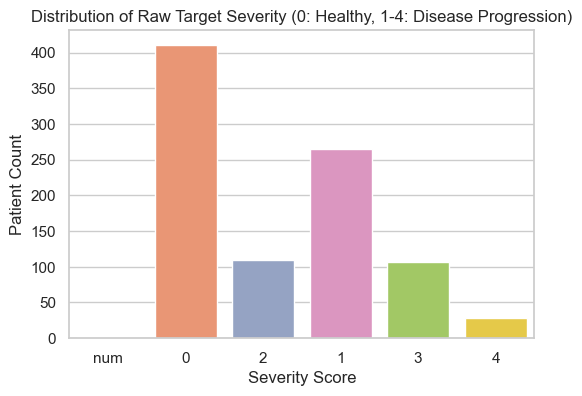

In [29]:
# Visualizing Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title('Distribution of Raw Target Severity (0: Healthy, 1-4: Disease Progression)')
plt.xlabel('Severity Score')
plt.ylabel('Patient Count')
plt.show()


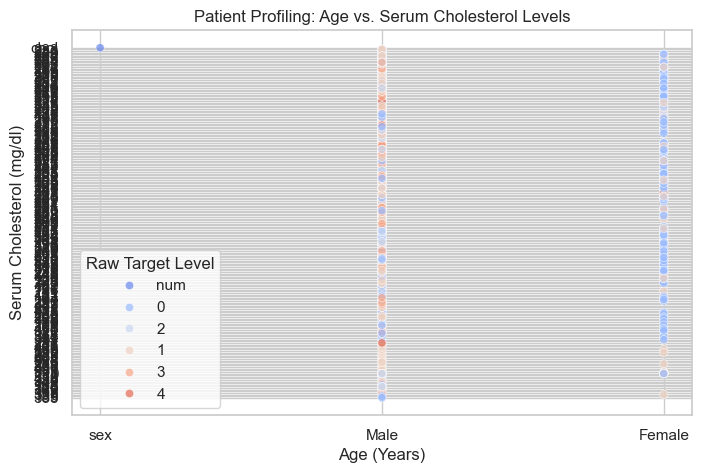

In [30]:

# Visualizing Age vs. Cholesterol levels colored by target visibility
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='chol', hue='target', palette='coolwarm', alpha=0.7)
plt.title('Patient Profiling: Age vs. Serum Cholesterol Levels')
plt.xlabel('Age (Years)')
plt.ylabel('Serum Cholesterol (mg/dl)')
plt.legend(title='Raw Target Level')
plt.show()



#  3. Data Preprocessing & Feature Engineering
#  **Handling Missingness:** Columns `ca` and `thal` are dropped due to extreme missingness (>50% missing data across the 921-row dataset).
#  **Target Binarization:** Target values from 1 to 4 are converted to `1` (Disease Present), and 0 remains `0` (No Disease).
#  **Advanced Imputation (MICE):** Continuous data is imputed via linear variations, while nominal data uses mode strategies.


In [31]:
# 3.1 Feature Dropping
df = df.drop(columns=['ca', 'thal'], errors='ignore')

# 3.2 Target Cleaning & Standardizing to Binary Classes
df['target'] = pd.to_numeric(df['target'], errors='coerce')
df = df.dropna(subset=['target'])
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Isolate features and target arrays
X = df.drop(columns=['target'], errors='ignore')
y = df['target']

# Cast categorical features as explicit string objects to protect pipeline formatting
for col in ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']:
    if col in X.columns:
        X[col] = X[col].astype(str)

# 3.3 Stratified Training and Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Partitions Formed Successfully.")
print(f"Training Features Shape: {X_train.shape} | Holdout Evaluation Features Shape: {X_test.shape}")



Data Partitions Formed Successfully.
Training Features Shape: (736, 11) | Holdout Evaluation Features Shape: (184, 11)


#  4. Model Development & Technology Stack
#  **Tech Stack:** Python 3, Pandas, Scikit-Learn, XGBoost, Matplotlib, Seaborn.
#  **Algorithms:** Baseline (Logistic Regression), Tree Ensemble (Random Forest), and Boosting Ensemble (XGBoost Classifier).
#  **Evaluation Metric:** Primary focus is **Recall (Sensitivity)** to catch all actual positive cases, backed by **ROC-AUC** for discriminatory accuracy.


*"In clinical risk stratification, a False Negative is significantly more critical than a False False Positive. If the model mistakenly flags a healthy patient as high-risk (False Positive), a secondary clinical test will correct the error with minimal overall harm.

However, if the model mistakenly flags an actively developing cardiac patient as low-risk (False Negative), that individual is sent home without treatment, creating a catastrophic clinical vulnerability. Therefore, Recall is targeted as our true north metric to ensure the system catches the highest proportion of true positive cardiac risks possible."*

In [32]:

# 4: MODEL DEVELOPMENT & TECHNOLOGY STACK 


# INLINE MEMORY PATCH: Force any residual strings in memory to pure numeric dummies immediately
X_train_numeric = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test_numeric = pd.get_dummies(X_test, drop_first=True, dtype=float)

# Ensure the column features perfectly align between splits if certain text categories were uneven
X_train_numeric, X_test_numeric = X_train_numeric.align(X_test_numeric, join='left', axis=1, fill_value=0.0)

# Single-stream pipeline processing purely numerical matrices
preprocessor = Pipeline([
    ('mice_imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('scaler', StandardScaler())
])

# Initialize Estimators
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Framework Storage Objects for Performance Mapping Graphs
results_summary = []
fitted_pipelines = {}

print("Executing Stratified 5-Fold Cross-Validation Framework...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Construct a beautifully clean, unified pipeline for each estimator
    clf_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Validation Performance Metrics Calculation (Using the newly patched pure numeric arrays)
    cv_recalls = cross_val_score(clf_pipeline, X_train_numeric, y_train, cv=cv, scoring='recall')
    cv_aucs = cross_val_score(clf_pipeline, X_train_numeric, y_train, cv=cv, scoring='roc_auc')
    
    # Fit Pipeline on Full Train Split
    clf_pipeline.fit(X_train_numeric, y_train)
    fitted_pipelines[name] = clf_pipeline
    
    # Predict on Holdout
    y_pred = clf_pipeline.predict(X_test_numeric)
    y_proba = clf_pipeline.predict_proba(X_test_numeric)[:, 1]
    
    # Score metrics
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    
    results_summary.append({
        'Model': name,
        'CV Recall': cv_recalls.mean(),
        'Test Recall': rec,
        'Test ROC-AUC': auc,
        'Test Accuracy': acc,
        'Predictions': y_pred,
        'Probabilities': y_proba
    })
    
    print(f"🤖 Finished Model: {name:20s} | Test Recall: {rec:.4f} | Test AUC: {auc:.4f}")

Executing Stratified 5-Fold Cross-Validation Framework...
🤖 Finished Model: Logistic Regression  | Test Recall: 0.8333 | Test AUC: 0.7972
🤖 Finished Model: Random Forest        | Test Recall: 0.9020 | Test AUC: 0.9070
🤖 Finished Model: XGBoost              | Test Recall: 0.8725 | Test AUC: 0.9151



#  4.2 Model Performance Visualizations
# We now visually plot the final test metrics to select our production model.


In [33]:
# Convert performance storage dictionary array into a structural DataFrame
df_metrics = pd.DataFrame(results_summary)


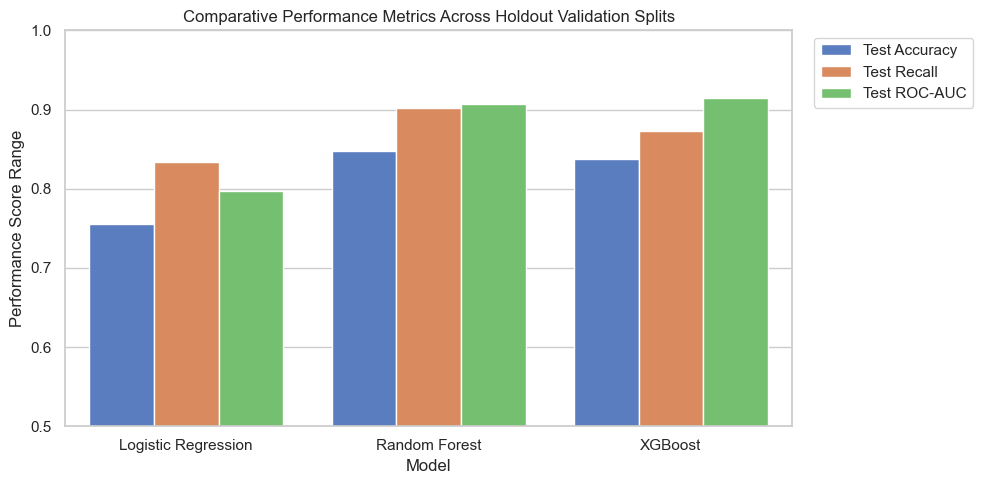

In [34]:
# Plot Model Metric Comparisons
df_melted = pd.melt(df_metrics, id_vars="Model", value_vars=["Test Accuracy", "Test Recall", "Test ROC-AUC"], 
                    var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="muted")
plt.title("Comparative Performance Metrics Across Holdout Validation Splits")
plt.ylim(0.5, 1.0)
plt.ylabel("Performance Score Range")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


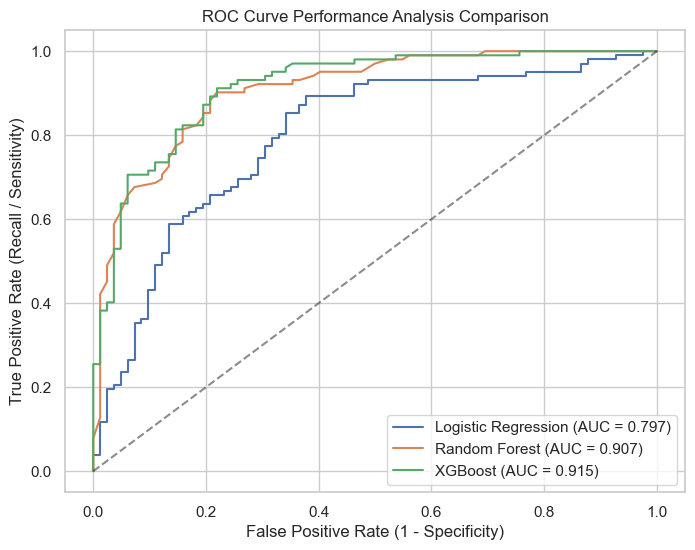

In [35]:
# Plot ROC Curves for all candidate models
plt.figure(figsize=(8, 6))
for name in models.keys():
    idx = df_metrics[df_metrics['Model'] == name].index[0]
    y_proba = df_metrics.loc[idx, 'Probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {df_metrics.loc[idx, 'Test ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('ROC Curve Performance Analysis Comparison')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.legend(loc='lower right')
plt.show()



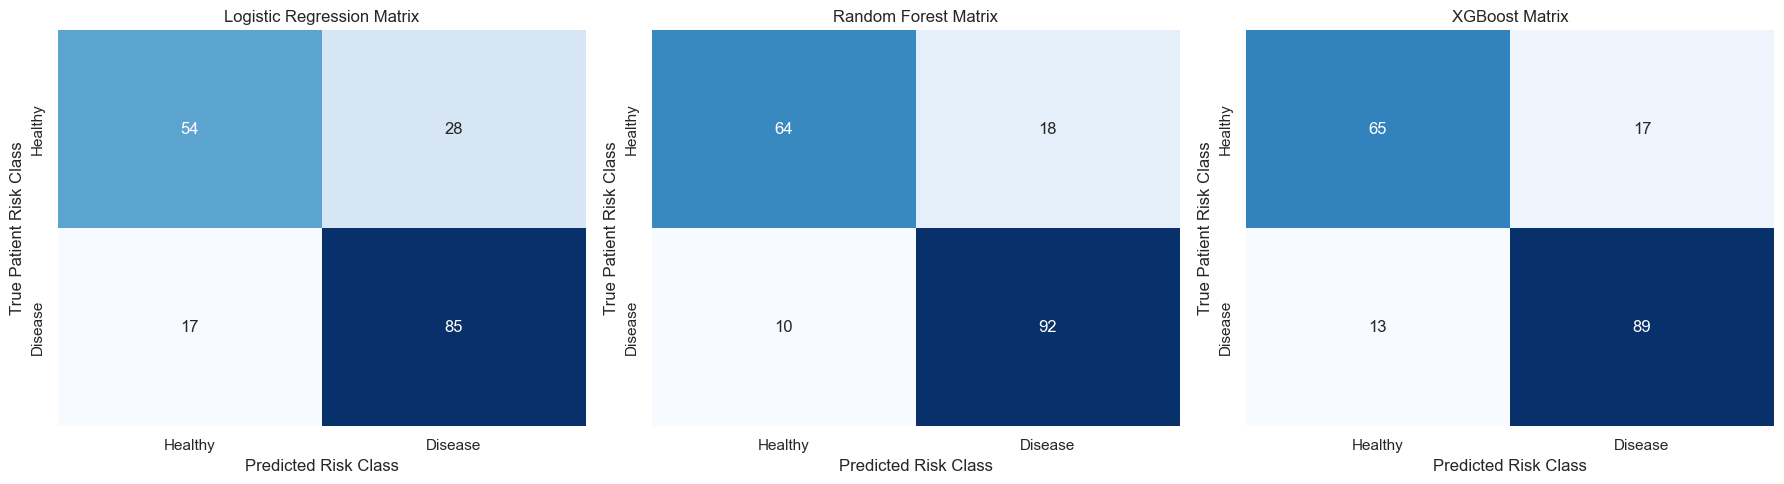

In [36]:
# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, pipeline) in enumerate(fitted_pipelines.items()):
    y_pred = df_metrics.loc[idx, 'Predictions']
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name} Matrix")
    axes[idx].set_xlabel('Predicted Risk Class')
    axes[idx].set_ylabel('True Patient Risk Class')
    axes[idx].set_xticklabels(['Healthy', 'Disease'])
    axes[idx].set_yticklabels(['Healthy', 'Disease'])

plt.tight_layout()
plt.show()




#  5. Business Interpretation & Patient-Risk Stratification Report
#  **Translating Data to Decisions:** Instead of using binary classification outputs (`0` or `1`), we sort raw probability vectors into operational patient care buckets.


In [38]:
# =====================================================================
# STEP 5: BUSINESS INTERPRETATION & RISK STRATIFICATION REPORT (FIXED)
# =====================================================================

# 1. Identify our champion model based on highest Test Recall
champion_name = df_metrics.sort_values(by='Test Recall', ascending=False).iloc[0]['Model']
champion_pipeline = fitted_pipelines[champion_name]

# 2. FIX: Generate probability values using the aligned numeric test matrix from Step 4
demo_probs = champion_pipeline.predict_proba(X_test_numeric)[:, 1]

# 3. Construct a beautiful, readable reporting table using original non-dummy index positions
# This lets us display clean text labels ('Male', chest pain types) in the final presentation
df_strat = df.loc[X_test_numeric.index].copy()
df_strat['True_Status'] = y_test
df_strat['Risk_Probability'] = demo_probs

# 4. Define our explicit operational clinical triage boundaries
def assign_tier(p):
    if p < 0.35: 
        return '🟢 LOW RISK (Routine Care Tracking)'
    elif p < 0.70: 
        return '🟡 MEDIUM RISK (Automated Lifestyle Coaching)'
    else: 
        return '🔴 HIGH RISK (Urgent Specialist Clinical Referral)'

df_strat['Patient_Risk_Stratification'] = df_strat['Risk_Probability'].apply(assign_tier)

# 5. Output presentation summary window
print(f"=== BUSINESS DECISION STRATIFICATION PREVIEW (Champion Model: {champion_name}) ===")
columns_to_show = ['age', 'sex', 'cp', 'trestbps', 'chol', 'Risk_Probability', 'Patient_Risk_Stratification']
display(df_strat[columns_to_show].head(10))

=== BUSINESS DECISION STRATIFICATION PREVIEW (Champion Model: Random Forest) ===


,,age,sex,cp,trestbps,chol,Risk_Probability,Patient_Risk_Stratification
515,49,Male,Hungary,asymptomatic,130,206,0.21,🟢 LOW RISK (Routine Care Tracking)
826,61,Male,VA Long Beach,asymptomatic,120,282,0.94,🔴 HIGH RISK (Urgent Specialist Clinical Referral)
855,55,Male,VA Long Beach,asymptomatic,172,260,0.79,🔴 HIGH RISK (Urgent Specialist Clinical Referral)
805,65,Male,VA Long Beach,asymptomatic,136,248,0.96,🔴 HIGH RISK (Urgent Specialist Clinical Referral)
888,69,Male,VA Long Beach,non-anginal,NaN,271,0.76,🔴 HIGH RISK (Urgent Specialist Clinical Referral)
484,59,Male,Hungary,non-anginal,130,318,0.79,🔴 HIGH RISK (Urgent Specialist Clinical Referral)
274,71,Female,Cleveland,asymptomatic,112,149,0.46,🟡 MEDIUM RISK (Automated Lifestyle Coaching)
541,50,Male,Hungary,asymptomatic,130,233,0.97,🔴 HIGH RISK (Urgent Specialist Clinical Referral)
403,48,Male,Hungary,atypical angina,140,238,0.06,🟢 LOW RISK (Routine Care Tracking)
602,38,Female,Switzerland,asymptomatic,105,0,0.64,🟡 MEDIUM RISK (Automated Lifestyle Coaching)


🟢 LOW RISK ($p < 0.35$): Routine Care TrackingClinical Action: Discharge to regular annual screening.Business Impact: Minimizes hospital bed congestion and avoids exposing the patient to unnecessary, expensive diagnostic bills.

🟡 MEDIUM RISK ($0.35 \le p < 0.70$): Automated Lifestyle CoachingClinical Action: Enrolls the patient automatically into remote monitoring apps, assigning digital dietary and preventive cardiac routines.Business Impact: Scalable preventative care that acts as a middle tier before conditions escalate, keeping patient engagement high without overextending active staff resources.

🔴 HIGH RISK ($p \ge 0.70$): Urgent Specialist Clinical ReferralClinical Action: Immediate high-priority booking with a consulting cardiologist for advanced diagnostic testing (e.g., echocardiogram, stress test).Business Impact: Directs high-value clinical focus directly to the individuals who need life-saving interventions immediately, maximizing the hospital’s operational efficiency.


#  6. Prototype / Dashboard & Deployment Blueprint
# **Deployment Architecture Blueprint:** #   * *Data Ingestion:* Hospital EHR databases securely push raw variables into the pipeline backend.
#    *Processing Layer:* A containerized API processes input arrays, handling missing records dynamically via our validated **MICE pipeline parameters**.
#    *Inference:* The optimal model performs real-time execution and returns continuous probability scores.
#    *Actionable Frontend:* Dashboard layouts display stratified patient distributions dynamically to hospital care providers.
#  **Deployment Challenges:** Navigating strict healthcare data privacy parameters (e.g., handling patient data securely), protecting pipelines against demographic/feature drift, and developing software hooks into legacy medical software stacks.